In [4]:
import sys
import pandas as pd
import numpy as np
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# ====================== KONFIGURASI ======================
N_ESTIMATORS = 9      # jumlah pohon -- naikkan kalau dataset makin besar/variatif
MAX_DEPTH = 3          # kedalaman tiap pohon -- jaga kecil agar tetap ringan di ESP32
RANDOM_STATE = 42
OUTPUT_HEADER = "rf_model.h"

FEATURES = [
    "Hujan ADC", "Hujan %", "Soil ADC", "Soil %",
    "accel_magnitude", "gyro_magnitude", "pitch", "roll",
]

# Mapping nama kolom dataset -> nama variabel di kode C (HARUS sama dengan
# parameter classifyRiskRF() di receiver_edge_gateway.ino)
CVAR = {
    "Hujan ADC": "rainADC",
    "Hujan %": "rainPct",
    "Soil ADC": "soilADC",
    "Soil %": "soilPct",
    "accel_magnitude": "accelMag",
    "gyro_magnitude": "gyroMag",
    "pitch": "pitch",
    "roll": "roll",
}

# Urutan kelas HARUS konsisten dengan riskClassToString() di rf_model.h
# (LabelEncoder akan urutkan alfabetis: Aman=0, Bahaya=1, Waspada=2)
EXPECTED_CLASS_ORDER = ["Aman", "Bahaya", "Waspada"]


def load_dataset(paths):
    dfs = []
    for p in paths:
        df = pd.read_csv(p, sep=None, engine="python", decimal=",")
        df.columns = [c.strip() for c in df.columns]
        dfs.append(df)
    full = pd.concat(dfs, ignore_index=True)

    # --- Bersihkan baris kosong / tidak lengkap (umum terjadi karena baris
    # kosong nyangkut di akhir file CSV saat export dari Excel/Sheets) ---
    before = len(full)
    required_cols = FEATURES + ["Label"]
    full = full.dropna(subset=required_cols).reset_index(drop=True)
    removed = before - len(full)
    if removed > 0:
        print(f"[INFO] {removed} baris kosong/tidak lengkap dibuang otomatis.")

    # --- Cek duplikat exact (boleh saja terjadi wajar pada sensor ADC,
    # tapi tetap diinfokan untuk transparansi) ---
    dup_count = full.duplicated(subset=required_cols).sum()
    if dup_count > 0:
        print(f"[INFO] Ditemukan {dup_count} baris duplikat persis (tidak dibuang otomatis).")

    print(f"[INFO] Total data setelah dibersihkan & digabung: {len(full)} baris")
    counts = full["Label"].value_counts()
    print(counts)

    # --- Peringatan ketidakseimbangan kelas ---
    if len(counts) > 0:
        ratio = counts.max() / counts.min()
        if ratio >= 1.5:
            print(f"\n[PERINGATAN] Distribusi kelas tidak seimbang (rasio {ratio:.1f}x antara "
                  f"kelas terbanyak '{counts.idxmax()}' dan tersedikit '{counts.idxmin()}').")
            print("             Model otomatis diberi class_weight='balanced' untuk mengompensasi,")
            print("             tapi idealnya jumlah sampel per kelas dibuat lebih rata saat")
            print("             pengumpulan data berikutnya.")

    return full


def evaluate_model(X, y, class_names):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    rf = RandomForestClassifier(
        n_estimators=N_ESTIMATORS, max_depth=MAX_DEPTH, random_state=RANDOM_STATE,
        class_weight="balanced"
    )
    scores = cross_val_score(rf, X, y, cv=skf)
    print(f"\n[HASIL] Cross-validation accuracy (5-fold): {scores}")
    print(f"[HASIL] Rata-rata akurasi: {scores.mean()*100:.2f}%")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
    )
    rf_eval = RandomForestClassifier(
        n_estimators=N_ESTIMATORS, max_depth=MAX_DEPTH, random_state=RANDOM_STATE,
        class_weight="balanced"
    )
    rf_eval.fit(X_train, y_train)
    pred = rf_eval.predict(X_test)

    print("\n[HASIL] Classification report (test set):")
    print(classification_report(y_test, pred, target_names=class_names))
    print("[HASIL] Confusion matrix (baris=aktual, kolom=prediksi):")
    print(class_names)
    print(confusion_matrix(y_test, pred))

    if scores.mean() < 0.85:
        print("\n[PERINGATAN] Akurasi cross-validation di bawah 85%.")
        print("  -> Pertimbangkan tambah data, cek label yang mungkin salah,")
        print("     atau tambah N_ESTIMATORS/MAX_DEPTH sedikit.")


def gen_tree_code(tree, func_name):
    t = tree.tree_
    lines = [
        f"int {func_name}(int rainADC, int rainPct, int soilADC, int soilPct, "
        f"float accelMag, float gyroMag, float pitch, float roll) {{"
    ]

    def recurse(node, depth):
        indent = "  " * (depth + 1)
        if t.feature[node] != -2:  # bukan leaf
            fname = CVAR[FEATURES[t.feature[node]]]
            thresh = t.threshold[node]
            lines.append(f"{indent}if ({fname} <= {thresh:.3f}f) {{")
            recurse(t.children_left[node], depth + 1)
            lines.append(f"{indent}}} else {{")
            recurse(t.children_right[node], depth + 1)
            lines.append(f"{indent}}})")
        else:
            cls = int(np.argmax(t.value[node][0]))
            lines.append(f"{indent}return {cls};")

    recurse(0, 0)
    lines.append("}")
    return "\n".join(lines)


def generate_header(rf, class_names, n_samples):
    tree_codes = [
        gen_tree_code(est, f"treeVote_{i}") for i, est in enumerate(rf.estimators_)
    ]
    n_trees = len(rf.estimators_)

    vote_calls = "\n".join(
        f"  votes[treeVote_{i}(rainADC, rainPct, soilADC, soilPct, accelMag, "
        f"gyroMag, pitch, roll)]++;"
        for i in range(n_trees)
    )

    class_switch = "\n".join(
        f"    case {i}: return \"{name.upper()}\";" for i, name in enumerate(class_names)
    )

    header = f'''/*\n  =====================================================================
  TANAALERT - MODEL RANDOM FOREST (rf_model.h)
  =====================================================================
  File ini di-generate OTOMATIS oleh train_and_generate.py

  Konfigurasi training:
    - Jumlah data latih : {n_samples} sampel
    - n_estimators       : {n_trees} pohon
    - max_depth          : {MAX_DEPTH}

  Mapping kelas (urutan ini ditentukan otomatis oleh LabelEncoder,
  JANGAN diubah manual):
{chr(10).join(f"    {i} = {name}" for i, name in enumerate(class_names))}
  =====================================================================
*/

#ifndef RF_MODEL_H
#define RF_MODEL_H

// ====================== {n_trees} POHON KEPUTUSAN (HASIL TRAINING) ======================

{chr(10).join(tree_codes)}

// ====================== VOTING (RANDOM FOREST) ======================
int classifyRiskRF(int rainADC, int rainPct, int soilADC, int soilPct,
                    float accelMag, float gyroMag, float pitch, float roll) {{
  int votes[{len(class_names)}] = {{{", ".join(["0"] * len(class_names))}}};\n
{vote_calls}\n
  int bestClass = 0;
  for (int i = 1; i < {len(class_names)}; i++) {{
    if (votes[i] > votes[bestClass]) bestClass = i;
  }}
  return bestClass;
}}

inline String riskClassToString(int riskClass) {{
  switch (riskClass) {{
{class_switch}\n    default: return "UNKNOWN";
  }}
}}

#endif
'''
    with open(OUTPUT_HEADER, "w") as f:
        f.write(header)
    print(f"\n[OK] {OUTPUT_HEADER} berhasil di-generate ulang ({n_trees} pohon).")
    print("     Salin file ini ke folder receiver_edge_gateway, lalu upload ulang.")


def main():
    # Use the specific dataset path for Colab execution
    dataset_paths = ['/content/dataset_sensor_1200sampel.csv']

    df = load_dataset(dataset_paths)
    X = df[FEATURES].values

    le = LabelEncoder()
    y = le.fit_transform(df["Label"].values)
    class_names = list(le.classes_)

    if class_names != EXPECTED_CLASS_ORDER:
        print(f"[PERINGATAN] Urutan label terdeteksi: {class_names}")
        print(f"             (Biasanya: {EXPECTED_CLASS_ORDER})")
        print("             Pastikan riskClassToString() di kode C tetap sesuai urutan ini.")

    evaluate_model(X, y, class_names)

    # Latih model FINAL pakai SELURUH data (bukan cuma 80% training split)
    rf_final = RandomForestClassifier(
        n_estimators=N_ESTIMATORS, max_depth=MAX_DEPTH, random_state=RANDOM_STATE,
        class_weight="balanced"
    )
    rf_final.fit(X, y)

    generate_header(rf_final, class_names, len(df))


if __name__ == "__main__":
    main()

[INFO] Ditemukan 900 baris duplikat persis (tidak dibuang otomatis).
[INFO] Total data setelah dibersihkan & digabung: 1200 baris
Label
Waspada    600
Bahaya     360
Aman       240
Name: count, dtype: int64

[PERINGATAN] Distribusi kelas tidak seimbang (rasio 2.5x antara kelas terbanyak 'Waspada' dan tersedikit 'Aman').
             Model otomatis diberi class_weight='balanced' untuk mengompensasi,
             tapi idealnya jumlah sampel per kelas dibuat lebih rata saat
             pengumpulan data berikutnya.

[HASIL] Cross-validation accuracy (5-fold): [0.9625     0.9875     0.9875     0.94583333 0.96666667]
[HASIL] Rata-rata akurasi: 97.00%

[HASIL] Classification report (test set):
              precision    recall  f1-score   support

        Aman       1.00      1.00      1.00        48
      Bahaya       0.95      0.99      0.97        72
     Waspada       0.99      0.97      0.98       120

    accuracy                           0.98       240
   macro avg       0.98      0.

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Re-create X, y, class_names, X_test, y_test, and pred for visualization
# This block replicates parts of the main() and evaluate_model() functions

# Load dataset again
dataset_paths = ['/content/dataset_sensor_1200sampel.csv']
df = load_dataset(dataset_paths)
X = df[FEATURES].values

# Encode labels again
le = LabelEncoder()
y = le.fit_transform(df["Label"].values)
class_names = list(le.classes_)

# Split data for evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# Train a model for evaluation to get predictions
rf_eval = RandomForestClassifier(
    n_estimators=N_ESTIMATORS, max_depth=MAX_DEPTH, random_state=RANDOM_STATE,
    class_weight="balanced"
)
rf_eval.fit(X_train, y_train)
pred = rf_eval.predict(X_test)

[INFO] Ditemukan 900 baris duplikat persis (tidak dibuang otomatis).
[INFO] Total data setelah dibersihkan & digabung: 1200 baris
Label
Waspada    600
Bahaya     360
Aman       240
Name: count, dtype: int64

[PERINGATAN] Distribusi kelas tidak seimbang (rasio 2.5x antara kelas terbanyak 'Waspada' dan tersedikit 'Aman').
             Model otomatis diberi class_weight='balanced' untuk mengompensasi,
             tapi idealnya jumlah sampel per kelas dibuat lebih rata saat
             pengumpulan data berikutnya.


### Confusion Matrix Visualization

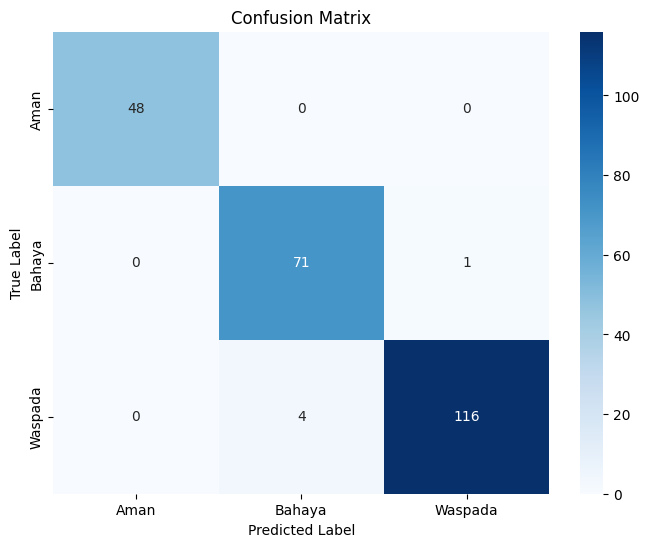

In [7]:
cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()